In [204]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib ipympl

# Echauffement : le broadcasting
print('questions concernant a')

a = np.array([1, 2, 3])
# 1. visualisation de l'action du None
print(a, a.shape)
print(a[:, None], a[:, None].shape)
print(a[None, :], a[None, :].shape)

# 2. forme du tableau X : (3,3) ; X[i,j]=i-j
X=a[:, None]-a[None, :]
print(X, X.shape)

# 3. 
print('questions concernant b')
# forme de b[:, None, :] -> (2,1,3)
# forme de b[:, :, None] -> (2,3,1)
# donc forme du tableau calculé : (2,3,3)
b=np.array([[1,2,3],[4,5,6]])
print(b, b.shape)
Y= b[:, None, :] - b[:, :, None]
print(Y,Y.shape)

questions concernant a
[1 2 3] (3,)
[[1]
 [2]
 [3]] (3, 1)
[[1 2 3]] (1, 3)
[[ 0 -1 -2]
 [ 1  0 -1]
 [ 2  1  0]] (3, 3)
questions concernant b
[[1 2 3]
 [4 5 6]] (2, 3)
[[[ 0  1  2]
  [-1  0  1]
  [-2 -1  0]]

 [[ 0  1  2]
  [-1  0  1]
  [-2 -1  0]]] (2, 3, 3)


In [205]:
# Initialisation aléatoire

# les bornes pour le tirage au sort initial
mass_max = 3.
    
x_min, x_max = -10., 10.
y_min, y_max = -10., 10.

speed_max = 1.
# # # # #

def init_problem(N):
    """
    retourne un tuple masses, positions, speeds
    de formes resp.   (N,)    (2, N)     (2, N)
    tiré au sort dans les bornes définies ci-dessus
    """
    masses=np.random.uniform(0,mass_max,(N,))

    positionsx, positionsy =  np.random.uniform(x_min,x_max,(N,)), np.random.uniform(y_min,y_max,(N,))
    positionsx, positionsy = positionsx[None, :], positionsy[None, :] # empaquetage de chaque ligne pour avoir 2 lignes différentes lors de la concaténation
    positions = np.concatenate((positionsx, positionsy), axis=0)

    speedsx, speedsy =  np.random.uniform(0,speed_max,(N,)), np.random.uniform(0,speed_max,(N,))
    speedsx, speedsy=speedsx[None, :], speedsy[None, :]
    speeds = np.concatenate((speedsx, speedsy), axis=0)

    return masses, positions, speeds

# pour tester

# normalement vous devez pouvoir faire ceci

masses, positions, speeds = init_problem(10)

#print(masses, masses.shape)
#print(positions, positions.shape)
#print(speeds, speeds.shape)

# et ceci devrait afficher OK
try:
    assert masses.shape == (10,) and positions.shape == speeds.shape == (2, 10)
    print("OK")
except:
    print("KO")

OK


In [206]:
# Initialisation reproductible

def init3():
    # first element is sun-like: heavy, at the center, and no speed
    masses = np.array([3, 1, 1], dtype=float)
    positions = np.array([
        [0, 5, -5], 
        [0, 1, -1]], dtype=float)
    speeds = np.array([
        [0, -1, 1], 
        [0, 0, 0]], dtype=float)
    return masses, positions, speeds

In [207]:
# Les forces

def forces(masses, positions, G=1.0):
    """
    returns an array of shape (2,  N)
    that contains the force felt by each mass from all the others
    G is the Newton constant and by default is set to 1 
    (we have abstract units anyway)
    """
    # calcul des vecteurs r_j-r_i puis de leur norme
    diff= positions[:, None, :] - positions[:, :, None] #c'est le sens pour lequel diff[:,i,j] est effectivement le vecteur r_j-r_i quand on teste avec les valeurs connues
    #print(diff)
    dist = np.linalg.norm(diff, axis=0)
    np.fill_diagonal(dist, np.inf) # pour que les termes diagonaux de coeff soient nuls

    # calcul des termes de la somme (puis somme)
    pdtmasses= masses[:, None] * masses[None, :]
    coeff= G * pdtmasses / dist**3
    termes_vect= coeff[None, :, :] * diff
    ls_forces = np.sum(termes_vect, axis=2)

    return ls_forces

# pour tester, voici les valeurs attendues avec la config prédéfinie

masses, positions, speeds = init3()

#print(positions)

f = forces(masses, positions)

# should be true
print( np.all(np.isclose(f, np.array([
     [ 0.        , -0.12257258,  0.12257258],
     [ 0.        , -0.02451452,  0.02451452]]))) )

True


In [208]:
# Le simulateur

def simulate(masses, positions, speeds, dt=0.1, nb_steps=100):
    """
    should return the positions across time
    so an array of shape (nb_steps, 2, N)
    optional dt is the time step
    """
    #initialisation des tableaux stockant les positions au cours du temps
    dim, N = positions.shape
    trajectoires=np.zeros((nb_steps, dim, N))
    trajectoires[0, :, :]=positions
    speeds2=np.copy(speeds) # une copie du tableau passé en paramètre qui pourra être modifiée par la suite

    for step in range(1, nb_steps): #calcul de proche en proche des positions au cours du temps
        ls_forces=forces(masses, trajectoires[step-1, :, :])
        acc = ls_forces / masses[None, :]
        speeds2 += dt*acc
        trajectoires[step, :, :] = trajectoires[step-1, :, :] + dt*speeds2

    return trajectoires

# pour tester la forme

SMALL_STEPS = 4

s = simulate(masses, positions, speeds, nb_steps=SMALL_STEPS)

try:
    if s.shape == (SMALL_STEPS, 2, 3):
        print("shape OK")
except Exception as exc:
    print(f"OOPS {type(exc)} {exc}")

# pour tester la trajectoire (premier point seulement)

positions1 = s[1]

print( np.all(np.isclose(positions1, np.array([
    [ 0.        ,  4.89877427, -4.89877427],
    [ 0.        ,  0.99975485, -0.99975485]]))) )


shape OK
True


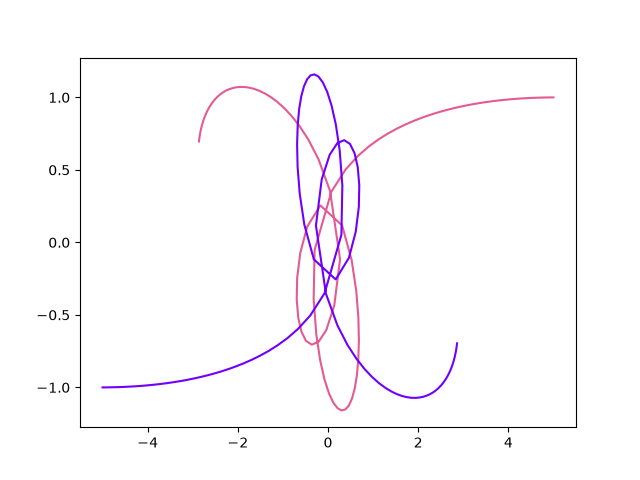

In [ ]:
# Dessiner

def draw(simulation, masses, colors=None, scale=10.):
    """
    takes as input the result of simulate() above,
    and draws the nb_steps positions of each of the N bodies
    ideally it should return a matplotlib Axes object

    one can provide a collection of N colors to use for each body
    if not provided this is randomized

    also the optional scale parameter is used as a constant
    multiplier to obtain the final size of each dot on the figure
    """
    N = len(masses)

    if colors is None :
        colors=np.random.uniform(0, 255, (N,3))/255

    plt.figure()
    for i in range(N):
        plt.plot(simulation[:,0,i], simulation[:,1,i], color=colors[i,:])
    plt.show()

# test affichage

colors3 = np.array([
    [32, 32, 32],
    (228, 90, 146),
    (111, 0, 255),
]) / 255

masses, positions, speeds = init3()
draw(simulate(masses, positions, speeds), masses, colors3)